# Previsão do Melhor Modo de Compra

## Objetivo

Este projeto tem como objetivo desenvolver um modelo de Machine Learning
capaz de prever o melhor modo de compra de um consumidor, considerando
características relacionadas ao seu comportamento de compras.


###Features (Tradução)

Occupation_Status
Situação Ocupacional

Country_Region
País/Região

Monthly_Income_Range
Faixa de Renda Mensal

Shop_Most_Where
Onde Compra com Mais Frequência

Online_Shopping_Frequency
Frequência de Compras Online

Preferred_Platform
Plataforma Preferida

Primary_Device
Dispositivo Principal

Top_Spending_Category
Categoria de Maior Gasto

Review_Influence_Score
Pontuação de Influência das Avaliações

Social_Ads_Influence_Score
Pontuação de Influência dos Anúncios nas Redes Sociais

Price_Comparison_Frequency
Frequência de Comparação de Preços

Discount_Importance_Score
Pontuação de Importância dos Descontos

Follows_Brands_On_Social
Segue Marcas nas Redes Sociais

Likely_To_Buy_After_Ad_Score
Pontuação de Probabilidade de Compra Após Anúncio

Makes_Shopping_List
Faz Lista de Compras

Impulse_Purchase_Frequency
Frequência de Compras por Impulso

Return_Frequency
Frequência de Devoluções

Avg_Monthly_Spend_NonEssentials
Gasto Médio Mensal com Itens Não Essenciais

Preferred_Payment_Method
Método de Pagamento Preferido

Uses_BNPL_Installments
Usa Parcelamento "Compre Agora, Pague Depois" (BNPL)

Online_Shopping_Satisfaction_Score
Pontuação de Satisfação com Compras Online

Trust_In_Online_Reviews_Score
Pontuação de Confiança em Avaliações Online

Regret_After_Purchase_Frequency
Frequência de Arrependimento Após a Compra

Reason_Prefer_Online
Motivo para Preferir Compras Online

Reason_Prefer_InStore
Motivo para Preferir Compras em Loja Física

Best_Shopping_Mode
Melhor Modalidade de Compra


#Bibliotecas

In [108]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#Carregamento dos dados

In [109]:
df = pd.read_csv("/content/consumer_shopping_behavior_survey.csv")

df.head(200)

,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,30/06/2026 13:23:02,20,Female,Student,Germany,"$1,000-3,000",Equal mix,Always,Physical stores,...,Sometimes,$50-150,Digital wallet,"No, never",7.0,7.0,3.0,Not applicable,No delivery wait,Online
196,197,09/08/2026 17:16:57,21,Male,Student,Brazil,"Under $1,000",Equal mix,Occasionally,Local e-commerce,...,Never,$150-300,Credit Card,"Yes, regularly",8.0,7.0,2.0,Convenience,Trust,Online
197,198,08/07/2026 16:32:31,20,Female,Student,Poland,"Under $1,000",Equal mix,Occasionally,Brand websites,...,Sometimes,$50-150,Cash,"Yes, occasionally",8.0,4.0,2.0,Convenience,NaN,Offline
198,199,16/07/2026 20:30:01,21,Male,Student,South Africa,"Under $1,000",Equal mix,Occasionally,Brand websites,...,Sometimes,$50-150,Debit Card,"No, never",6.0,4.0,1.0,Convenience,Try product before buying,Online


#Análise exploratória

In [110]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Response_ID                         500 non-null    int64  
 1   Timestamp                           500 non-null    object 
 2   Age                                 478 non-null    object 
 3   Gender                              484 non-null    object 
 4   Occupation_Status                   479 non-null    object 
 5   Country_Region                      480 non-null    object 
 6   Monthly_Income_Range                479 non-null    object 
 7   Shop_Most_Where                     484 non-null    object 
 8   Online_Shopping_Frequency           481 non-null    object 
 9   Preferred_Platform                  486 non-null    object 
 10  Primary_Device                      492 non-null    object 
 11  Top_Spending_Category               476 non-n

,0
Response_ID,0
Timestamp,0
Age,22
Gender,16
Occupation_Status,21
Country_Region,20
Monthly_Income_Range,21
Shop_Most_Where,16
Online_Shopping_Frequency,19
Preferred_Platform,14


###Escolha da minha target (Melhor Modalidade de Compra)

In [111]:
X = df.drop(columns=["Response_ID", "Timestamp", "Best_Shopping_Mode"])

y = df["Best_Shopping_Mode"]

#Preparação dos dados

###Explicando o uso da função dropna:
Ao tentar separar treino/teste eu estava tomando erro: "ValueError: Input contains NaN", ou seja minha variavel target contem valores nulos e o stratify=y precisa conhecer todas as classes do alvo, e ele não aceita valores nulos. E não faz sentido imputar o target, por isso a escolha de remover essas linhas.

In [112]:
df = df.dropna(subset=["Best_Shopping_Mode"])

X = df.drop(columns=["Best_Shopping_Mode"])
y = df["Best_Shopping_Mode"]

###Separarando treino e teste

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###Separarando features numéricas e categóricas

In [114]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

In [115]:
print("Numéricas:")
print(numeric_features)

print("\nCategóricas:")
print(categorical_features)

Numéricas:
Index(['Response_ID', 'Review_Influence_Score', 'Social_Ads_Influence_Score',
       'Price_Comparison_Frequency', 'Discount_Importance_Score',
       'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency',
       'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score',
       'Regret_After_Purchase_Frequency'],
      dtype='object')

Categóricas:
Index(['Timestamp', 'Age', 'Gender', 'Occupation_Status', 'Country_Region',
       'Monthly_Income_Range', 'Shop_Most_Where', 'Online_Shopping_Frequency',
       'Preferred_Platform', 'Primary_Device', 'Top_Spending_Category',
       'Follows_Brands_On_Social', 'Makes_Shopping_List', 'Return_Frequency',
       'Avg_Monthly_Spend_NonEssentials', 'Preferred_Payment_Method',
       'Uses_BNPL_Installments', 'Reason_Prefer_Online',
       'Reason_Prefer_InStore'],
      dtype='object')


In [116]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

numeric_features

Index(['Response_ID', 'Review_Influence_Score', 'Social_Ads_Influence_Score',
       'Price_Comparison_Frequency', 'Discount_Importance_Score',
       'Likely_To_Buy_After_Ad_Score', 'Impulse_Purchase_Frequency',
       'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score',
       'Regret_After_Purchase_Frequency'],
      dtype='object')

###FEATURES NUMERICAS
###Tratando valores nulos (imputer)
opções: mean | median | most_frequent

Antes de definir a estratégia do SimpleImputer, foi realizada uma análise das variáveis numéricas utilizando describe(), histogramas e grafico. Como a distribuição das variáveis não apresentou quantidade significativa de outliers, optei por utilizar strategy="mean" (média)

---



In [117]:
X_train[numeric_features].describe()

,Response_ID,Review_Influence_Score,Social_Ads_Influence_Score,Price_Comparison_Frequency,Discount_Importance_Score,Likely_To_Buy_After_Ad_Score,Impulse_Purchase_Frequency,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency
count,359.000000,349.000000,347.000000,340.000000,340.000000,338.000000,348.000000,348.000000,343.000000,340.000000
mean,244.587744,3.085960,3.115274,4.164706,3.852941,3.062130,2.606322,7.149425,6.215743,2.182353
std,142.529473,1.148989,1.206185,0.929326,0.993559,1.089054,1.145177,1.561635,1.931605,0.913185
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,120.500000,2.000000,2.000000,4.000000,3.000000,2.000000,2.000000,6.000000,5.000000,1.000000
50%,241.000000,3.000000,3.000000,4.000000,4.000000,3.000000,2.000000,7.000000,6.000000,2.000000
75%,364.500000,4.000000,4.000000,5.000000,5.000000,4.000000,3.000000,8.000000,7.000000,3.000000
max,499.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,10.000000,4.000000


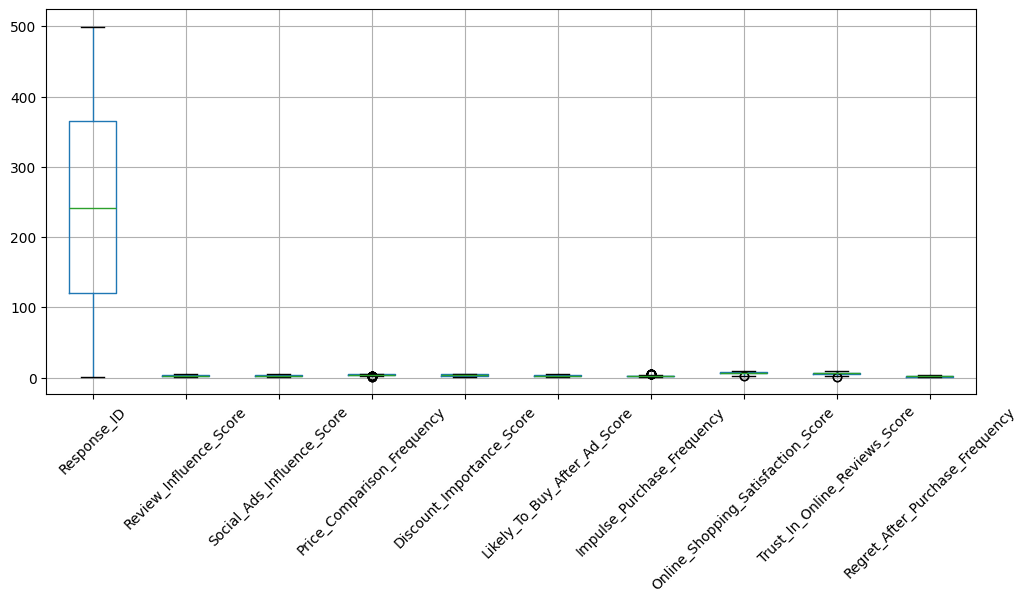

In [118]:
import matplotlib.pyplot as plt

X_train[numeric_features].boxplot(figsize=(12,5))
plt.xticks(rotation=45)
plt.show()

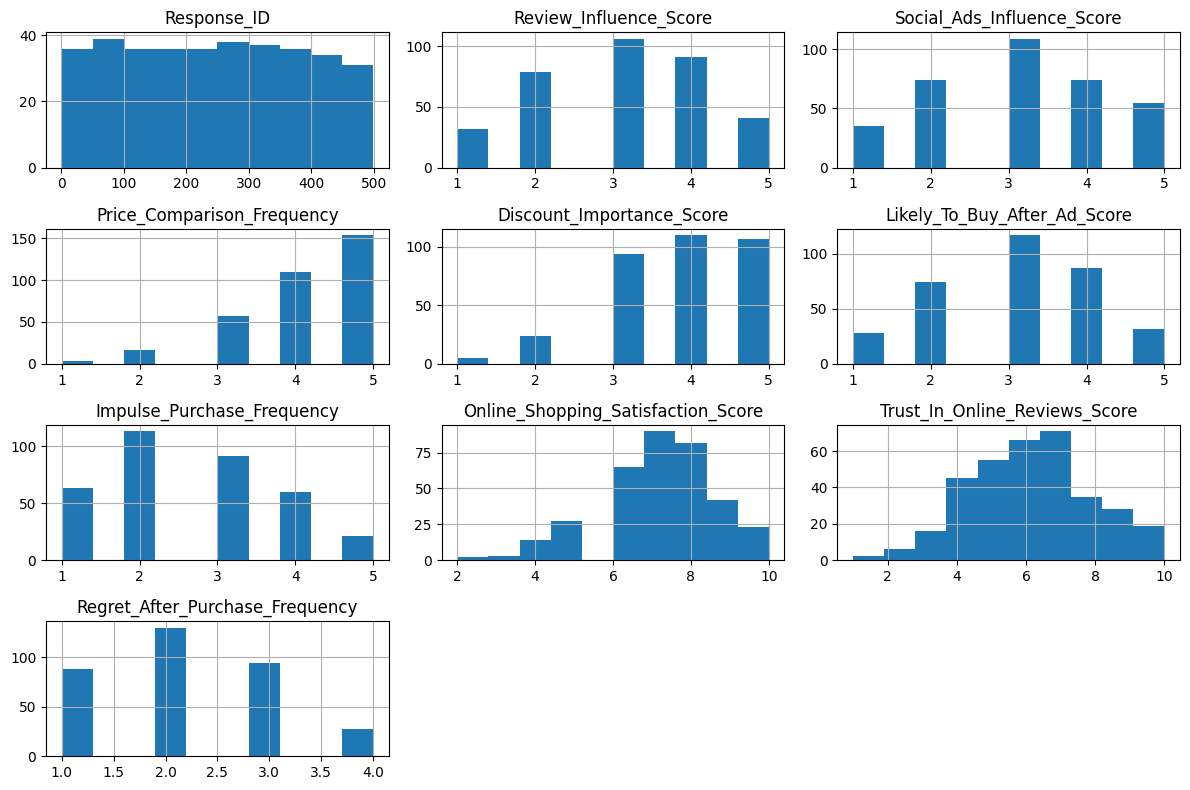

In [119]:
X_train[numeric_features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [120]:
num_imputer = SimpleImputer(strategy="mean")

X_train_num = num_imputer.fit_transform(X_train[numeric_features])
X_test_num = num_imputer.transform(X_test[numeric_features])


###FEATURES CATEGORICAS

In [121]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat = cat_imputer.fit_transform(
    X_train[categorical_features]
)

X_test_cat = cat_imputer.transform(
    X_test[categorical_features]
)

###Encoder

O handle_unknown="ignore" evita erro caso apareça uma categoria nova no teste.

In [122]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train_cat)

X_test_cat = encoder.transform(X_test_cat)

###Padronizando as variaveis numericas (Scaller)

In [123]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)

X_test_num = scaler.transform(X_test_num)

###Juntando os dados

In [124]:
X_train_processed = np.concatenate(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_processed = np.concatenate(
    [X_test_num, X_test_cat],
    axis=1
)

In [125]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(359, 484)
(90, 484)


###Treinando modelos
max_iter = número máximo de iterações que o algoritmo pode fazer para encontrar os parâmetros do modelo.

Modelo 1 — Regressão Logística

In [126]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_processed, y_train)

pred_log = log_model.predict(X_test_processed)

Macro -> Como o modelo se comporta considerando todas as classes igualmente

Weighted -> Como o modelo se comporta considerando também a quantidade de exemplos de cada classe.

Support -> quantidade de exemplos por classe

In [127]:
print("Accuracy:", accuracy_score(y_test, pred_log))

print(classification_report(y_test, pred_log))

Accuracy: 0.5333333333333333
              precision    recall  f1-score   support

Equal / both       0.19      0.23      0.20        22
     Offline       0.69      0.46      0.55        24
      Online       0.68      0.73      0.70        44

    accuracy                           0.53        90
   macro avg       0.52      0.47      0.49        90
weighted avg       0.56      0.53      0.54        90



###Modelo 2 — Decision Tree

In [128]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

pred_tree = tree_model.predict(X_test_processed)

In [129]:
print("Accuracy:", accuracy_score(y_test, pred_tree))

print(classification_report(y_test, pred_tree))

Accuracy: 0.5111111111111111
              precision    recall  f1-score   support

Equal / both       0.12      0.09      0.10        22
     Offline       0.62      0.62      0.62        24
      Online       0.59      0.66      0.62        44

    accuracy                           0.51        90
   macro avg       0.44      0.46      0.45        90
weighted avg       0.48      0.51      0.50        90



###Modelo 3 — Random Forest

In [130]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train_processed, y_train)

pred_forest = forest_model.predict(X_test_processed)

In [131]:
print("Accuracy:", accuracy_score(y_test, pred_forest))

print(classification_report(y_test, pred_forest))

Accuracy: 0.5777777777777777
              precision    recall  f1-score   support

Equal / both       0.22      0.09      0.13        22
     Offline       0.69      0.46      0.55        24
      Online       0.60      0.89      0.72        44

    accuracy                           0.58        90
   macro avg       0.50      0.48      0.46        90
weighted avg       0.53      0.58      0.53        90



###Avaliação

In [132]:
results = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_tree),
        accuracy_score(y_test, pred_forest)
    ]
})

results.sort_values("Accuracy", ascending=False)

,Modelo,Accuracy
2,Random Forest,0.577778
0,Regressão Logística,0.533333
1,Decision Tree,0.511111


###Matriz de confusão
O que realmente aconteceu × O que o modelo previu

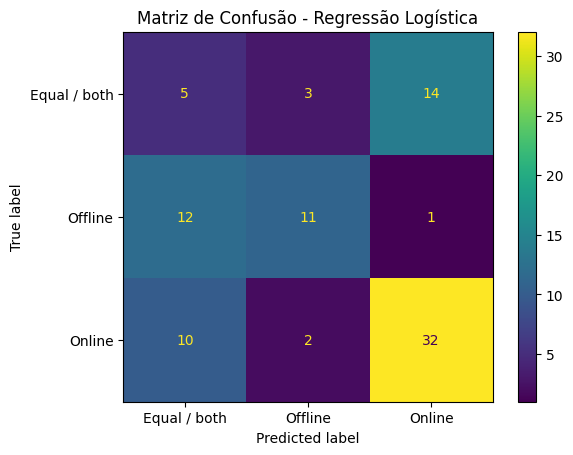

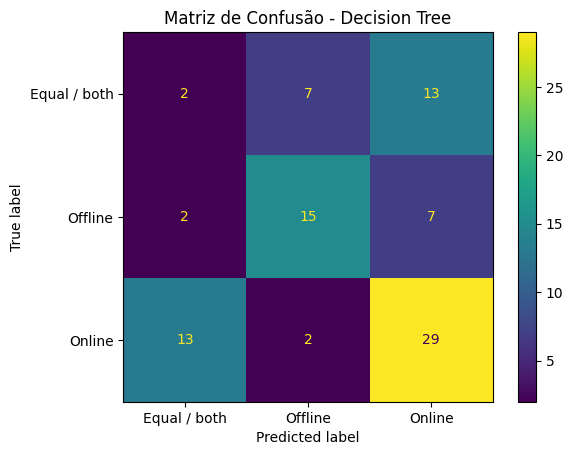

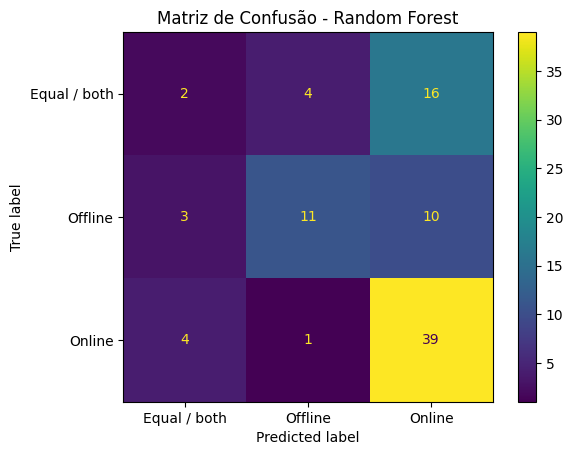

In [133]:
modelos = {
    "Regressão Logística": log_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

for nome, modelo in modelos.items():

    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_test_processed,
        y_test
    )

    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()